In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import glob
import xml.etree.ElementTree as ET

import librosa

import numpy as np


# Clasificación de cantos de aves

El dataset:

"Manually labeled Bird song dataset of 22 species from Xeno-canto to enhance deep learning acoustic classifiers with contextual information."

Jeantet Lorene1
 
Dufourq Emmanuel


Fue descargado de la pagina de Zenodo. Zenodo es un repositorio de Open Science (Ciencia Abierta) operado por el CERN (la Organización Europea para la Investigación Nuclear) en Ginebra. 

Los autores recopilan la informacion de xenocanto (otro dataset mas grande) y tomaron solo los audios de mejor calidad.
De este modo tomaron 967 audios en donde se detectan 8660 ocurrencias

Hay un archivo csv, ese archivo es el catálogo de las grabaciones de audio que los autores de descargaron de la enorme base de datos original www.xeno-canto.org.



## Análisis de los archivos de Annotation

Los autores tomaron los archivos de xenocanto y armaron este dataset.

In [43]:
import os
import glob
import xml.etree.ElementTree as ET
from collections import defaultdict

annotation_dir = "c:/Users/nahue/Documents/Ceia/VPC2/Trabajo_beta/Annotation"
svl_files = glob.glob(os.path.join(annotation_dir, "**/*.svl"), recursive=True)

species_files = defaultdict(int)
species_occurrences = defaultdict(int)

for file in svl_files:
    # Filename format: Family_genus_species_country of recording_date_ID_song.svl
    # So we can extract genus and species from the file name, or from the folder if there are any, or just from the label tag
    filename = os.path.basename(file)
    parts = filename.split('_')
    if len(parts) >= 3:
        species_name = parts[1] + " " + parts[2]
    else:
        species_name = "Unknown"
        
    species_files[species_name] += 1
    
    # Parse XML to count occurrences
    try:
        tree = ET.parse(file)
        root = tree.getroot()
        # Find all point elements in the dataset
        points = root.findall(".//point")
        species_occurrences[species_name] += len(points)
    except Exception as e:
        print(f"Error parsing {file}: {e}")

print("Especie | Grabaciones | Ocurrencias")
print("-" * 50)
for sp in sorted(species_files.keys()):
    print(f"{sp:30} | {species_files[sp]:5} | {species_occurrences[sp]:5}")


Especie | Grabaciones | Ocurrencias
--------------------------------------------------
Catharus aurantiirostris       |    68 |   713
Catharus bicknelli             |     6 |    72
Catharus fuscater              |    29 |   416
Catharus fuscescens            |    24 |   236
Catharus guttatus              |    37 |   547
Catharus minimus               |    16 |   123
Catharus ustulatus             |    33 |   310
Hypocnemis cantator            |    32 |   167
Hypocnemis hypoxantha          |    29 |   160
Hypocnemis peruviana           |    33 |   221
Hypocnemis striata             |    11 |    55
Saxicola gutturalis            |     8 |    44
Saxicola rubetra               |    87 |  1917
Saxicola rubicola              |    70 |   636
Saxicola tectes                |    12 |    74
Saxicola torquatus             |     8 |    33
Serinus canicollis             |    14 |    71
Serinus serinus                |    83 |   633
Troglodytes aedon              |   120 |   826
Troglodytes hiemalis

Aqui armamos el dataframe master que tiene toda la informacion de los audios seleccionados de xenocanto por los autores.
Esta informacion esta en la carpeta annotation

In [ ]:




import os
import glob
import pandas as pd
import xml.etree.ElementTree as ET

def svl_to_dataframe(svl_file_path):
    """
    Función base: Extrae la información de un solo archivo y la devuelve como una lista de diccionarios.
    Además, guarda de qué archivo y de qué subcarpeta (Training o Validation) provino la ocurrencia.
    """
    tree = ET.parse(svl_file_path)
    root = tree.getroot()
    
    # Extraer el SampleRate
    model_tag = root.find('.//model')
    sample_rate = float(model_tag.get('sampleRate', 44100)) if model_tag is not None else 44100.0
    
    # Extraer información de origen del archivo
    nombre_archivo = os.path.basename(svl_file_path)
    carpeta_origen = os.path.basename(os.path.dirname(svl_file_path)) # Sabremos si es 'Training' o 'Validation'
    
    data = []
    
    for point in root.findall('.//point'):
        frame = float(point.get('frame', 0))
        duration = float(point.get('duration', 0))
        freq_min = float(point.get('value', 0))
        freq_extent = float(point.get('extent', 0))
        label = point.get('label', 'Desconocido')
        
        start_time_sec = frame / sample_rate
        duration_sec = duration / sample_rate
        end_time_sec = start_time_sec + duration_sec
        freq_max = freq_min + freq_extent
        
        # Agregamos los datos de ocurrencia + metadata de archivo a la lista
        data.append({
            'nombre_archivo': nombre_archivo,
            'carpeta': carpeta_origen,
            'especie_label': label,
            'frecuencia_min_hz': freq_min,
            'frecuencia_max_hz': freq_max,
            'tiempo_inicio_sec': start_time_sec,
            'tiempo_fin_sec': end_time_sec,
            'duracion_sec': duration_sec
        })
        
    return data

# =========================================================================
# PASO 2: BUSCAR TODOS LOS ARCHIVOS Y CREAR EL GRAN DATAFRAME MAESTRO
# =========================================================================

# 1. Definir la ruta a tu carpeta global de anotaciones
# Usa comillas simples o dobles. Según exploré en tu directorio de trabajo, esta es la ruta:
ruta_base = "Annotation"

# 2. Utilizar glob para encontrar TODOS los archivos .svl de forma recursiva
# **/*.svl buscará tanto dentro de 'Training' como de 'Validation'
svl_files = glob.glob(os.path.join(ruta_base, "**/*.svl"), recursive=True)

print(f"Buscando... ¡Se han encontrado {len(svl_files)} archivos de grabaciones (archivos .svl)!")

# 3. Lista maestra que acumulará TODAS las ocurrencias de todos los archivos
todas_las_ocurrencias = []

for archivo in svl_files:
    try:
        # Llamar a la función para cada archivo y extraer sus ocurrencias
        ocurrencias_de_este_archivo = svl_to_dataframe(archivo)
        # Extender la lista maestra con estas nuevas ocurrencias
        todas_las_ocurrencias.extend(ocurrencias_de_este_archivo)
    except Exception as error:
        print(f"Hubo un pequeño error procesando {archivo}: {error}")

# 4. Crear finalmente el SUPER DataFrame maestro fusionado
df_master = pd.DataFrame(todas_las_ocurrencias)

print(f"¡Éxito! El DataFrame maestro contiene {len(df_master)} ocurrencias individuales de canto de aves.")

# Mostrar visualmente las primeras filas
display(df_master.head())



Buscando... ¡Se han encontrado 967 archivos de grabaciones (archivos .svl)!
¡Éxito! El DataFrame maestro contiene 8660 ocurrencias individuales de canto de aves.


,nombre_archivo,carpeta,especie_label,frecuencia_min_hz,frecuencia_max_hz,tiempo_inicio_sec,tiempo_fin_sec,duracion_sec
0,Fringillidae_Serinus_canicollis_South Africa_2...,Training,"Fringillidae_Serinus_canicollis,9",1913.66,9157.61,0.000000,3.599093,3.599093
1,Fringillidae_Serinus_canicollis_South Africa_2...,Training,"Fringillidae_Serinus_canicollis,9",1895.32,9010.90,4.133152,7.685805,3.552653
2,Fringillidae_Serinus_canicollis_South Africa_2...,Training,"Fringillidae_Serinus_canicollis,9",1601.89,8955.87,10.216780,14.373152,4.156372
3,Fringillidae_Serinus_canicollis_South Africa_2...,Training,"Fringillidae_Serinus_canicollis,9",1638.57,8974.21,15.418050,19.110023,3.691973
4,Fringillidae_Serinus_canicollis_South Africa_2...,Training,"Fringillidae_Serinus_canicollis,9",1491.86,9084.25,20.363900,23.521814,3.157914


In [26]:
archivo_auditado = "Troglodytidae_Troglodytes_troglodytes_Portugal_2022-02-24_XC708550_song"
# Construimos una Máscara Booleana con doble condición:
# 1. Que el nombre del archivo incluya parte de nuestro string objetivo
# 2. Que el segundo inicial del canto sea menor o igual a 15.0 segundos.
rastreo_temporal = df_master[
    (df_master['nombre_archivo'].str.contains(archivo_auditado)) & 
    (df_master['tiempo_inicio_sec'] >= 0.0) & 
    (df_master['tiempo_inicio_sec'] <= 15.0)
]


rastreo_temporal

,nombre_archivo,carpeta,especie_label,frecuencia_min_hz,frecuencia_max_hz,tiempo_inicio_sec,tiempo_fin_sec,duracion_sec
4118,Troglodytidae_Troglodytes_troglodytes_Portugal...,Training,"Troglodytidae_Troglodytes_troglodytes,8",2574.59,8312.11,0.053333,1.733333,1.680000
4119,Troglodytidae_Troglodytes_troglodytes_Portugal...,Training,"Troglodytidae_Troglodytes_troglodytes,8",2895.57,8633.09,11.253333,13.946667,2.693333


In [46]:
df_master.to_pickle('df_master.pkl')

In [3]:
df_master = pd.read_pickle('df_master.pkl')

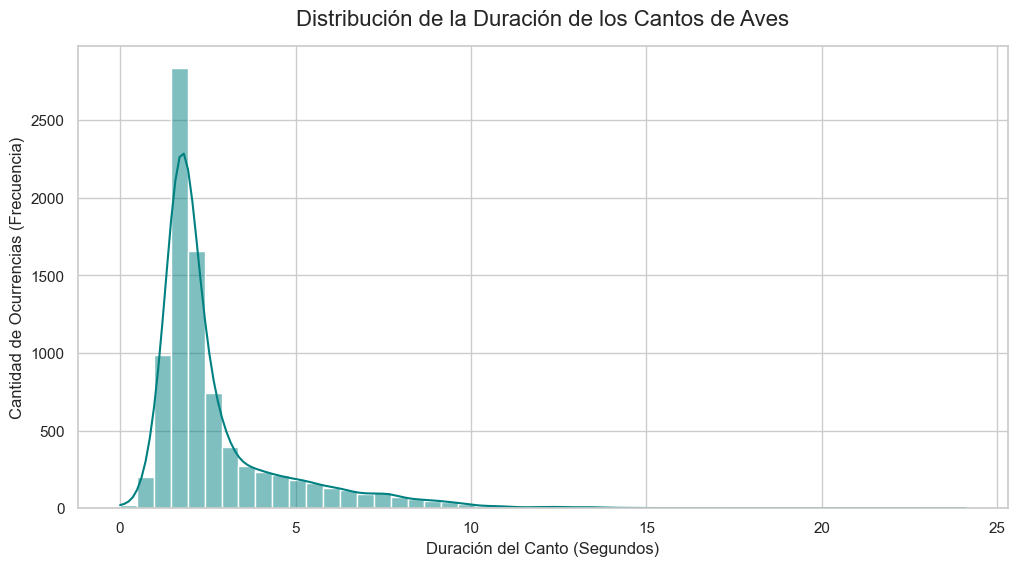

--- Resumen Estadístico de las Duraciones (en segundos) ---
count    8660.000000
mean        2.727584
std         1.952083
min         0.000021
25%         1.625397
50%         1.984000
75%         2.925714
max        24.096508
Name: duracion_sec, dtype: float64


In [4]:
# Graficamos la duración de las ocurrencias 

# Configurar el estilo visual para que se vea profesional
sns.set_theme(style="whitegrid")

# Crear la figura (lienzo) con un tamaño fácil de leer
plt.figure(figsize=(12, 6))

# Graficar el histograma de la columna 'duracion_sec'
# bins=50 agrupa los datos en 50 barras; kde=True dibuja la curva de tendencia
sns.histplot(data=df_master, x='duracion_sec', bins=50, kde=True, color='teal')

# Agregar títulos y etiquetas a los ejes para entender el gráfico
plt.title('Distribución de la Duración de los Cantos de Aves', fontsize=16, pad=15)
plt.xlabel('Duración del Canto (Segundos)', fontsize=12)
plt.ylabel('Cantidad de Ocurrencias (Frecuencia)', fontsize=12)

# Mostrar el gráfico en el notebook
plt.show()

# Imprimir además los números exactos de la estadística descriptiva
print("--- Resumen Estadístico de las Duraciones (en segundos) ---")
print(df_master['duracion_sec'].describe())


In [16]:
df_train = df_master[df_master['carpeta'] == 'Training']
df_val = df_master[df_master['carpeta'] == 'Validation']

In [48]:
# Contar ocurrencias por especie solo en la carpeta de Training
conteos_train = df_train['especie_label'].value_counts()


In [49]:
# Quedarnos solo con el nombre de las especies que tengan >= 100 ocurrencias en Train
especies_robustas = conteos_train[conteos_train >= 100].index
# Filtrar nuestros DataFrames para borrar a las especies con pocos datos
df_train_robusto = df_train[df_train['especie_label'].isin(especies_robustas)]
df_val_robusto = df_val[df_val['especie_label'].isin(especies_robustas)]
print(f"Especies seleccionadas para entrenamiento ({len(especies_robustas)} especies):")
print(especies_robustas.tolist())

Especies seleccionadas para entrenamiento (16 especies):
['Paridae_Saxicola_rubetra,9', 'Troglodytidae_Troglodytes_aedon,9', 'Turdidae_Catharus_guttatus,9', 'Turdidae_Catharus_aurantiirostris,8', 'Troglodytidae_Troglodytes_troglodytes, 10', 'Troglodytidae_Troglodytes_troglodytes,9', 'Fringillidae_Serinus_serinus,9', 'Paridae_Saxicola_rubicola,9', 'Turdidae_Catharus_fuscater,9', 'Paridae_Saxicola_rubetra,8', 'Turdidae_Catharus_aurantiirostris,9', 'Troglodytidae_Troglodytes_hiemalis,9', 'Turdidae_Catharus_ustulatus,9', 'Paridae_Saxicola_rubicola,8', 'aridae_Saxicola_rubetra,9', 'Troglodytidae_Troglodytes_pacificus,9']


In [28]:
tiempo_ideal = df_train_robusto['duracion_sec'].quantile(0.90)
print(f"El 90% de los cantos dura {tiempo_ideal:.2f} segundos o menos.")


El 90% de los cantos dura 5.82 segundos o menos.


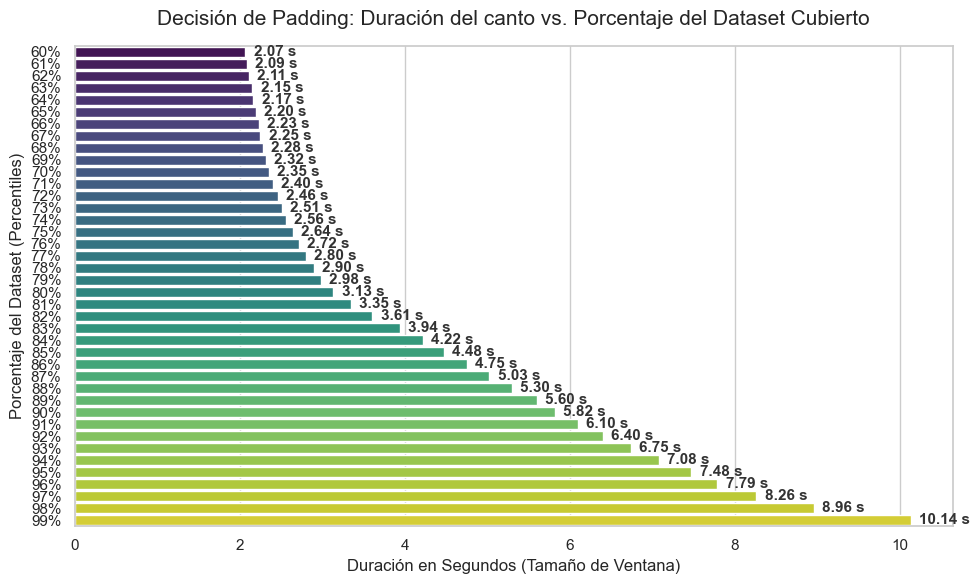

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir los porcentajes (cuantiles) que queremos ver: del 60% al 100% saltando de a 5%
percentiles = np.arange(0.60, 1, 0.01)

# 2. Calcular los valores de duración exacta en segundos para cada percentil
duraciones = df_train_robusto['duracion_sec'].quantile(percentiles)

# 3. Crear etiquetas legibles para el eje Y (ej: "60%", "65%")
etiquetas_y = [f"{int(p * 100)}%" for p in percentiles]

# 4. Configurar el gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Dibujar el gráfico de barras horizontales
sns.barplot(x=duraciones.values, y=etiquetas_y, hue=etiquetas_y, palette="viridis", legend=False)

# Añadir títulos y etiquetas a los ejes
plt.title('Decisión de Padding: Duración del canto vs. Porcentaje del Dataset Cubierto', fontsize=15, pad=15)
plt.xlabel('Duración en Segundos (Tamaño de Ventana)', fontsize=12)
plt.ylabel('Porcentaje del Dataset (Percentiles)', fontsize=12)

# 5. Escribir el número exacto (con 2 decimales) flotando al final de cada barra
for indice, valor in enumerate(duraciones.values):
    plt.text(valor + 0.1, indice, f"{valor:.2f} s", va='center', fontsize=11, fontweight='bold', color='#333333')

# Ajustar los márgenes automáticamente y mostrar
plt.tight_layout()
plt.show()


In [5]:
df_master

,nombre_archivo,carpeta,especie_label,frecuencia_min_hz,frecuencia_max_hz,tiempo_inicio_sec,tiempo_fin_sec,duracion_sec
0,Fringillidae_Serinus_canicollis_South Africa_2...,Training,"Fringillidae_Serinus_canicollis,9",1913.660,9157.610,0.000000,3.599093,3.599093
1,Fringillidae_Serinus_canicollis_South Africa_2...,Training,"Fringillidae_Serinus_canicollis,9",1895.320,9010.900,4.133152,7.685805,3.552653
2,Fringillidae_Serinus_canicollis_South Africa_2...,Training,"Fringillidae_Serinus_canicollis,9",1601.890,8955.870,10.216780,14.373152,4.156372
3,Fringillidae_Serinus_canicollis_South Africa_2...,Training,"Fringillidae_Serinus_canicollis,9",1638.570,8974.210,15.418050,19.110023,3.691973
4,Fringillidae_Serinus_canicollis_South Africa_2...,Training,"Fringillidae_Serinus_canicollis,9",1491.860,9084.250,20.363900,23.521814,3.157914
...,...,...,...,...,...,...,...,...
8655,Turdidae_Catharus_ustulatus_United States_2015...,Validation,"Turdidae_Catharus_ustulatus,9",1090.060,6426.350,74.474667,76.672000,2.197333
8656,Turdidae_Catharus_ustulatus_United States_2015...,Validation,"Turdidae_Catharus_ustulatus,9",1009.810,4620.830,1.685333,3.669333,1.984000
8657,Turdidae_Catharus_ustulatus_United States_2015...,Validation,"Turdidae_Catharus_ustulatus,9",1009.810,6707.200,12.437333,14.464000,2.026667
8658,Turdidae_Catharus_ustulatus_United States_2015...,Validation,"Turdidae_Catharus_ustulatus,9",849.325,4781.325,20.616000,22.536000,1.920000


In [6]:
df_master['frecuencia_max_hz'].max()

np.float64(21349.600500549997)

In [7]:
df_master.describe()

,frecuencia_min_hz,frecuencia_max_hz,tiempo_inicio_sec,tiempo_fin_sec,duracion_sec
count,8660.000000,8660.000000,8660.000000,8660.000000,8660.000000
mean,2042.212183,7522.247109,63.826217,66.553801,2.727584
std,798.447187,1807.151067,95.955498,95.936550,1.952083
min,-3724.640000,367.850000,0.000000,0.000023,0.000021
25%,1517.570000,6506.590000,13.160635,15.667664,1.625397
50%,1932.630000,7870.760000,32.368617,35.028317,1.984000
75%,2519.607500,8705.760000,71.489333,74.147120,2.925714
max,21349.600000,21349.600501,806.336000,808.213333,24.096508


In [8]:
conteos_groupby = df_master.groupby('especie_label').size().sort_values(ascending=False)
# Imprimir de forma bonita como un reporte
print("RANKING DE CANTOS POR ESPECIE (Vía GroupBy):")
print("-" * 50)
print(conteos_groupby)

RANKING DE CANTOS POR ESPECIE (Vía GroupBy):
--------------------------------------------------
especie_label
Paridae_Saxicola_rubetra,9                                                  1234
Troglodytidae_Troglodytes_aedon,9                                            683
Turdidae_Catharus_guttatus,9                                                 453
Troglodytidae_Troglodytes_troglodytes, 10                                    395
Turdidae_Catharus_aurantiirostris,8                                          379
                                                                            ... 
Paridae_Saxicola_rubetra                                                       1
Troglodytidae_Troglodytes_aedon,7                                              1
Paridae_Saxicola_rubicola                                                      1
Turdidae_Catharus_fuscater_Ecuador_2002-03-Turdidae_Catharus_fuscater,9        1
Troglodytidae_Troglodytes_troglodytes_Spain_2020-10-12_XC595581_song, 10       1

Pipeline End-to-End: Extracción Acústica y Generación de Tensores
Este bloque constituye el núcleo de procesamiento bioacústico (Feature Pipeline) del presente proyecto. Su función es tomar los metadatos y grabaciones sonoras "salvajes" y transformarlas en Tensores Matemáticos estandarizados (matrices en coma flotante) óptimos para ser ingeridos por redes neuronales convolucionales de Deep Learning.


1. Auditoría y Purga Estadística (Data Cleaning)
El pipeline inicia auditando el volumen de cantos anotados: Toda especie que no cuente con un mínimo de 100 ocurrencias en el dataset de entrenamiento puro es purgada de los registros. 

2. Homogeneización de Muestreo (Upsampling)
Las grabaciones originarias poseen distintos Sample Rates (micrófonos a 44.1 kHz, 48 kHz, y caídas de radio a 22.05 kHz). Si se cargan en estado puro, un espectrograma de 6 segundos arrojaría imágenes de distinto ancho en píxeles. El algoritmo implementa un Upsampling / Downsampling forzado por interpolación al vuelo hacia sr=44100, con lo cual garantiza que el 100% de los recortes generen una matriz dimensionalmente perfecta ([128 x 517]) de cara al empaquetamiento 3D de Numpy.

3. Padding Ambiental por Centrado Continuo
Las vocalizaciones individuales (Bounding Boxes) poseen en general una duración menor a la ventana requerida de 6.0 segundos. En lugar de inyectar Ceros Digitales (Zero-Padding) o concatenar audio asimétricamente desde el inicio (que inserta cortes o saltos de fase audibles en la señal que confunden a la IA), se diseñó un algoritmo de Centrado Continuo temporal. El algoritmo calcula matemáticamente el centro exacto del trino, y "abre" la ventana hacia atrás y hacia adelante (3 segundos por flanco). Esto inyecta de forma natural e ininterrumpida el "ruido de fondo" o silencios propios del ambiente que estaba capando el micrófono original.

4. Transformada de Fourier sobre Escala Mel y "Nicho Acústico"
Finalmente, la ventana acústica se pasa por una STFT (Short-Time Fourier Transform) y se transforma al dominio de las frecuencias envolviéndolo en 128 bandas de la Escala Mel (imitando el espectro y audibilidad logarítmica de los mamíferos). Apoyándonos teóricamente en la Hipótesis del Nicho Acústico, se impone una restricción de Ancho de Banda superior límite o de Corte en los 10.000 Hz (fmax=10000). Dado que más del 95% de energía armónica de los paseriformes existe entre 1.5 y 8 kHz, limitar la lupa visual hasta los 10 kHz fuerza a las redes neuronales a desechar el ruido estático inútil o ultrasónico de insectos y concentrar su matriz de pesos convolucionales específicamente donde existe información útil biológica.

In [ ]:
# ==============================================================================
# SÚPER BLOQUE MAESTRO 
# Construcción de Dataset: Resampling 256x256, Jitter, y Filtro de Ruido V6.1
# ==============================================================================

import os
import librosa
import numpy as np
import pandas as pd
import random 

# -------------------------------------------------------------------------
# 1. HIPERPARÁMETROS DEL DATASET ESTELAR
# -------------------------------------------------------------------------
DURACION_RED_NEURONAL_SEC = 6.0  
N_MELS = 256                     
FMAX = 10000                     
SAMPLE_RATE_TARGET = 21845       
UMBRAL_ESTADISTICO = 100         

# Cuotas Obligatorias para tu clase "Sin_Pajaro"
MAX_RUIDOS_TRAIN = 200           
MAX_RUIDOS_VAL = 50   

# Sensibilidad (0.01: mata silbidos puros de frente, deja vivir bosque de fondo)
UMBRAL_FLATNESS_DSP = 0.01           

# -------------------------------------------------------------------------
# 2. PURGA ESTADÍSTICA DE DATA
# -------------------------------------------------------------------------
print("=== FASE 1: AUDITORÍA DE CLASES ===")
conteo_especies = df_master['especie_label'].value_counts()
especies_robustas = conteo_especies[conteo_especies >= UMBRAL_ESTADISTICO].index
df_robusto = df_master[df_master['especie_label'].isin(especies_robustas)].copy()
print(f"Especies aprobadas por superar el umbral >= {UMBRAL_ESTADISTICO}: {len(especies_robustas)}")

# -------------------------------------------------------------------------
# 3. PRE-CÁLCULO: POOL DE DONANTES MILITARES PARA 'SIN_PAJARO'
# -------------------------------------------------------------------------
archivos_train = df_robusto[df_robusto['carpeta'] == 'Training']['nombre_archivo'].unique()
archivos_val = df_robusto[df_robusto['carpeta'] == 'Validation']['nombre_archivo'].unique()

donantes_ruido_train = set(random.sample(list(archivos_train), min(1200, len(archivos_train))))
donantes_ruido_val = set(random.sample(list(archivos_val), min(600, len(archivos_val))))
donantes_ruido_maestro = donantes_ruido_train.union(donantes_ruido_val)

# -------------------------------------------------------------------------
# 4. MEMORIA DINÁMICA DE TENSORES
# -------------------------------------------------------------------------
X_data = []      
y_labels = []    
carpetas = []    
nombres_imagenes_rastreo = [] 

archivos_unicos = df_robusto['nombre_archivo'].unique()
total_archivos = len(archivos_unicos)

contador_ruidos_train = 0
contador_ruidos_val = 0
falsos_destruidos = 0

print("\n=== FASE 2: MOTOR CONVOLUTIVO E INGESTA ACÚSTICA ===")

# -------------------------------------------------------------------------
# 5. EL BUCLE MAESTRO
# -------------------------------------------------------------------------
for indice, archivo in enumerate(archivos_unicos):
    
    if indice % 50 == 0:
        print(f"⏳ Extrayendo archivo {indice} de {total_archivos} (Ruidos T: {contador_ruidos_train}/{MAX_RUIDOS_TRAIN} | V: {contador_ruidos_val}/{MAX_RUIDOS_VAL})")

    cortes = df_robusto[df_robusto['nombre_archivo'] == archivo]
    carpeta = cortes['carpeta'].iloc[0] 
    ruta_mp3 = os.path.join("Audio_birds2", carpeta, archivo.replace('.svl', '.mp3'))
    
    if not os.path.exists(ruta_mp3): continue
        
    try:
        audio_completo, sr = librosa.load(ruta_mp3, sr=SAMPLE_RATE_TARGET)
        muestras_ventana_target = int(DURACION_RED_NEURONAL_SEC * sr)
        duracion_audio_sec = len(audio_completo) / sr
        
        # ==============================================================================
        # A. EXTRACTOR AGRESIVO "SIN_PAJARO" HASTA LLENAR CUOTA
        # ==============================================================================
        necesita_ruido = False
        if archivo in donantes_ruido_maestro:
            if carpeta == 'Training' and contador_ruidos_train < MAX_RUIDOS_TRAIN:
                necesita_ruido = True
            elif carpeta == 'Validation' and contador_ruidos_val < MAX_RUIDOS_VAL:
                necesita_ruido = True

        if necesita_ruido and duracion_audio_sec > DURACION_RED_NEURONAL_SEC:
            intentos = 0
            encontro_hueco_vacio = False
            ruido_aprobado = None
            posicion_final_inicio = 0
            
            # Persistencia de 40 intentos aleatorios para sortear los pájaros etiquetados
            while intentos < 40 and not encontro_hueco_vacio:
                posible_inicio = random.uniform(0.0, duracion_audio_sec - DURACION_RED_NEURONAL_SEC)
                posible_fin = posible_inicio + DURACION_RED_NEURONAL_SEC
                
                # Barrera 1: Colisión según Expertos XML
                colision = False
                for _, fila_paj in cortes.iterrows():
                    ave_ini = fila_paj['tiempo_inicio_sec']
                    ave_fin = fila_paj['tiempo_inicio_sec'] + fila_paj['duracion_sec']
                    if not (posible_fin < ave_ini or posible_inicio > ave_fin):
                        colision = True
                        break 
                
                # Barrera 2: Analítica DSP Librosa
                if not colision:
                    ini_ruido_temp = int(posible_inicio * sr)
                    fin_ruido_temp = int(posible_fin * sr)
                    candidato = audio_completo[ini_ruido_temp:fin_ruido_temp]
                    candidato = librosa.util.fix_length(candidato, size=muestras_ventana_target)
                    
                    if np.mean(librosa.feature.spectral_flatness(y=candidato)) < UMBRAL_FLATNESS_DSP:
                        colision = True 
                        falsos_destruidos += 1
                    else:
                        encontro_hueco_vacio = True 
                        ruido_aprobado = candidato
                        posicion_final_inicio = posible_inicio
                
                intentos += 1
                
            if encontro_hueco_vacio:
                mel_ruido = librosa.feature.melspectrogram(y=ruido_aprobado, sr=sr, n_mels=N_MELS, fmax=FMAX)
                mel_db_ruido = librosa.power_to_db(mel_ruido, ref=np.max) 
                
                X_data.append(mel_db_ruido)
                y_labels.append("Sin_Pajaro") 
                carpetas.append(carpeta) 
                
                identidad = f"RUIDO_en_{archivo.replace('.svl', '')}__segundo_{posicion_final_inicio:.1f}.png"
                nombres_imagenes_rastreo.append(identidad)
                
                if carpeta == 'Training': contador_ruidos_train += 1
                else: contador_ruidos_val += 1
        
        # ==============================================================================
        # B. EXTRACCIÓN AVES CON DATA AUGMENTATION (JITTER POSICIONAL)
        # ==============================================================================
        for idx, fila in cortes.iterrows():
            
            inicio_original_sec = fila['tiempo_inicio_sec']
            duracion_ave = fila['duracion_sec']
            
            if duracion_ave < DURACION_RED_NEURONAL_SEC:
                # Jitter traslacional (Mueve el pájaro de izquierda a derecha de forma randomizada)
                margen_disponible = DURACION_RED_NEURONAL_SEC - duracion_ave
                margen_izq = random.uniform(0.0, margen_disponible)
                nuevo_inicio_sec = inicio_original_sec - margen_izq
                nuevo_fin_sec = nuevo_inicio_sec + DURACION_RED_NEURONAL_SEC
            else:
                # Corte forzoso central por superación del límite temporal
                centro_sec = inicio_original_sec + (duracion_ave / 2.0)
                nuevo_inicio_sec = centro_sec - (DURACION_RED_NEURONAL_SEC / 2.0)
                nuevo_fin_sec = centro_sec + (DURACION_RED_NEURONAL_SEC / 2.0)
            
            muestra_inicio = int(nuevo_inicio_sec * sr)
            muestra_fin = int(nuevo_fin_sec * sr)
            
            if muestra_inicio < 0:
                muestra_inicio = 0; muestra_fin = muestras_ventana_target
            if muestra_fin > muestras_totales_audio:
                muestra_fin = muestras_totales_audio
                muestra_inicio = muestras_totales_audio - muestras_ventana_target
                if muestra_inicio < 0: muestra_inicio = 0 
            
            canto_procesado = audio_completo[muestra_inicio:muestra_fin]
            canto_procesado = librosa.util.fix_length(canto_procesado, size=muestras_ventana_target)
            
            mel_spec_potencia = librosa.feature.melspectrogram(y=canto_procesado, sr=sr, n_mels=N_MELS, fmax=FMAX)
            mel_spec_db = librosa.power_to_db(mel_spec_potencia, ref=np.max)
            
            X_data.append(mel_spec_db)
            y_labels.append(fila['especie_label'])
            carpetas.append(carpeta)
            
            identidad = f"PAJARO_en_{archivo.replace('.svl', '')}__segundo_{inicio_original_sec:.1f}.png"
            nombres_imagenes_rastreo.append(identidad)
            
    except Exception as error:
        pass 

# -------------------------------------------------------------------------
# 6. COMPILACIÓN EN NPY (V6_FINAL)
# -------------------------------------------------------------------------
print("\n=== FASE 3: VOLCADO A DISCO .NPY ===")
X = np.array(X_data)      
y = np.array(y_labels)    
splits = np.array(carpetas)
NOMBRES_DNI = np.array(nombres_imagenes_rastreo)

print(f"Dimensiones de Inteligencia Artificial listas: {X.shape}")
print(f"✅ Ruidos generados (Train): {contador_ruidos_train} / {MAX_RUIDOS_TRAIN}")
print(f"✅ Ruidos generados (Val): {contador_ruidos_val} / {MAX_RUIDOS_VAL}")
print(f"🛡️ Defensas: El Filtro Librosa aniquiló {falsos_destruidos} silbidos.")

np.save('X_espectrogramas_finales_V6.npy', X)
np.save('y_etiquetas_finales_V6.npy', y)
np.save('splits_carpetas_finales_V6.npy', splits)
np.save('NOMBRES_DNI_RASTREO.npy', NOMBRES_DNI)

print("\n✅ DATOS GUARDADOS.")


In [28]:
import os
import shutil
import matplotlib.pyplot as plt

# Definimos el nombre principal de la carpeta contenedora en tu Windows
carpeta_maestra = "Dataset_Imagenes_Robustas"

# =========================================================================
# 1. PROTOCOLO DE DESTRUCCIÓN PREVENTIVA (Evita mezclar fotos viejas)
# =========================================================================
if os.path.exists(carpeta_maestra):
    print(f"🗑️ Detectada la carpeta antigua '{carpeta_maestra}'. Aniquilándola...")
    shutil.rmtree(carpeta_maestra)

# =========================================================================
# 2. MOTOR DE RENDERIZACIÓN A PNG (8-Bits)
# =========================================================================
print("🎨 Renderizando la Base de Datos Visual V6.0 a tu rigido...")
print("⏱️ (Este proceso tomará un par de minutos dependiendo de tu procesador)")

# Recorremos el enorme cubo matemático de RAM
for i in range(len(X)):
    
    espectrograma_2d = X[i]
    especie_pajaro = y[i]
    conjunto = splits[i]
    
    # Extraemos el "Nombre-DNI" único y súper descriptivo que creamos
    nombre_DNI_foto = NOMBRES_DNI[i] 
    
    # Armamos las subcarpetitas dinámicamente según la etiqueta (Ej: Train -> Zonotrichia)
    ruta_subcarpeta = os.path.join(carpeta_maestra, conjunto, especie_pajaro)
    os.makedirs(ruta_subcarpeta, exist_ok=True) # Las crea si no existen
    
    # Escribimos el archivo final con compresión PNG + Mapa de Color "Viridis"
    ruta_guardado = os.path.join(ruta_subcarpeta, nombre_DNI_foto)
    plt.imsave(ruta_guardado, espectrograma_2d, cmap='viridis', origin='lower')

print("✅ ¡Éxito Masivo! Tu Base de Datos Científica Visual está lista para ser analizada.")


🗑️ Detectada la carpeta antigua 'Dataset_Imagenes_Robustas'. Aniquilándola...
🎨 Renderizando la Base de Datos Visual V6.0 a tu rigido...
⏱️ (Este proceso tomará un par de minutos dependiendo de tu procesador)
✅ ¡Éxito Masivo! Tu Base de Datos Científica Visual está lista para ser analizada.
